# 2.2. Transformations

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Hàm dùng để hiển thị ảnh

In [3]:
def show_plt(tittle, img):
    plt.title(tittle)
    plt.axis("off")

    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)

## Load ảnh

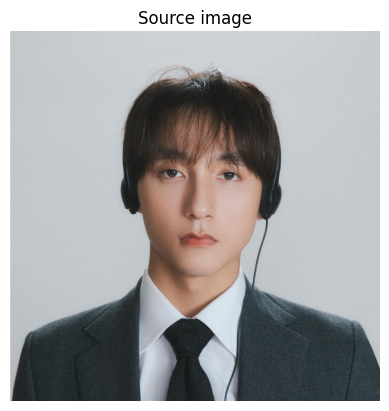

In [4]:
DATA_ROOT = "../Images/"
IMAGE_NAME = "sontung.jpg"

img_path = DATA_ROOT + IMAGE_NAME

img = cv2.imread(img_path, cv2.IMREAD_COLOR)

show_plt("Source image", img)

### Lấy height, width của ảnh

In [68]:
h, w = img.shape[:2]

### Translation

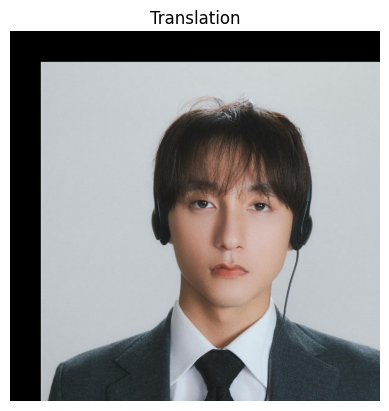

In [69]:
tx, ty = 50, 50

translation_matrix = np.array([
    [1, 0, tx],
    [0, 1, ty]
], dtype=np.float32)

translated_img = cv2.warpAffine(img, translation_matrix, (w, h))

show_plt("Translation", translated_img)

### Rotation

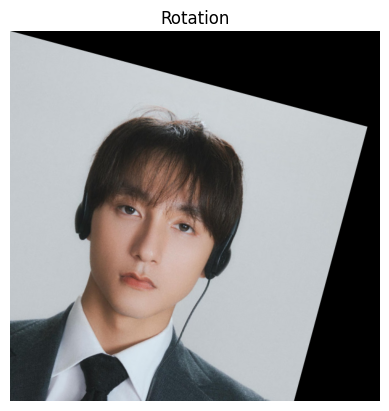

In [70]:
theta = np.deg2rad(15)

rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta), np.cos(theta), 0]
], dtype=np.float32)

rotated_image = cv2.warpAffine(img, rotation_matrix, (w,h))

show_plt("Rotation", rotated_image)

### Scaling

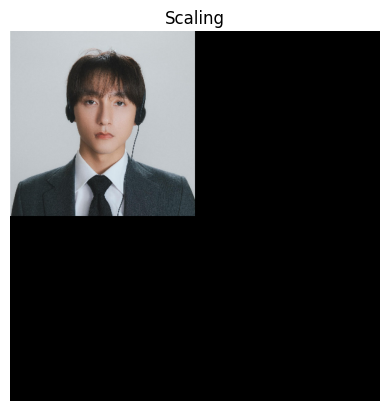

In [71]:
sx = 0.5
sy = 0.5

scaled_matrix = np.array([
    [sx, 0, 0],
    [0, sy, 0]
], dtype=np.float32)

scaled_img = cv2.warpAffine(img, scaled_matrix, (w, h))

show_plt("Scaling", scaled_img)

### Shearing

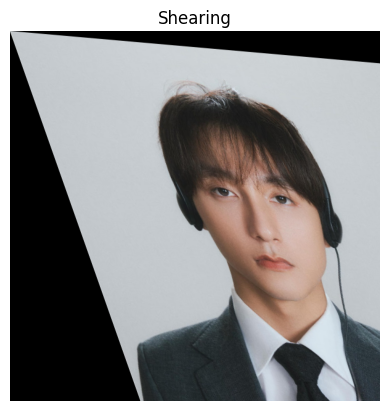

In [72]:
theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

sheared_matrix = np.array([
    [1, 1/np.tan(theta_x), 0],
    [1/np.tan(theta_y), 1 + 1/(np.tan(theta_x)*np.tan(theta_y)), 0]
], dtype=np.float32)

sheared_img = cv2.warpAffine(img, sheared_matrix, (w, h))

show_plt("Shearing", sheared_img)

## Affine transformation

### Xây dựng ma trận từ chuỗi phép biến đổi

#### Rotation + Translation

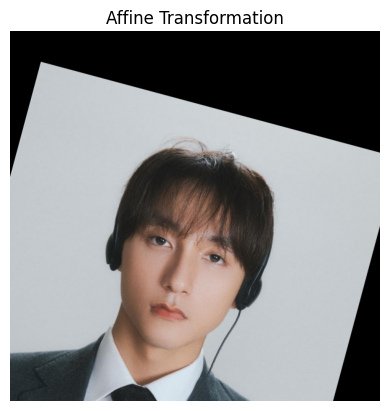

In [73]:
theta = np.deg2rad(15)
tx, ty = 50, 50

affine_matrix = np.array([
    [np.cos(theta), -np.sin(theta), tx],
    [np.sin(theta),  np.cos(theta), ty]
], dtype=np.float32)

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

#### Scaling + Translation

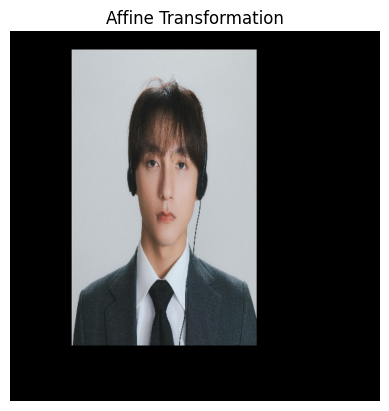

In [74]:
sx, sy = 0.5, 0.8
tx, ty = 100, 30

affine_matrix = np.array([
    [sx, 0, tx],
    [0, sy, ty]
], dtype=np.float32)

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

#### Rotation + Scaling

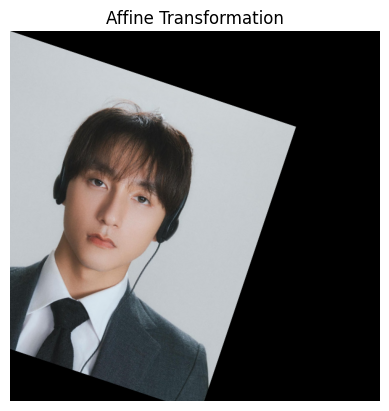

In [75]:
theta = np.deg2rad(15)
sx, sy = 0.8, 0.8

affine_matrix = np.array([
    [sx*np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  sy*np.cos(theta), 0]
], dtype=np.float32)

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

#### Shearing + Translation

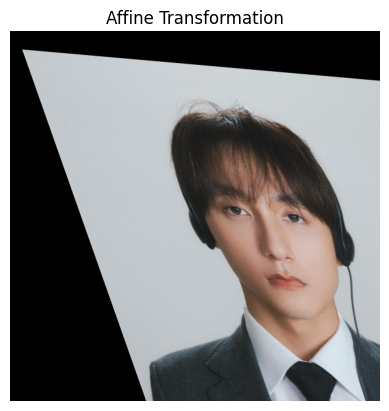

In [76]:
theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

shx = 1/np.tan(theta_x)
shy = 1/np.tan(theta_y)
tx, ty = 20, 30

affine_matrix = np.array([
    [1, shx, tx],
    [shy, 1 + shx*shy, ty]
], dtype=np.float32)

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

#### Rotation + Scaling + Shearing + Translation

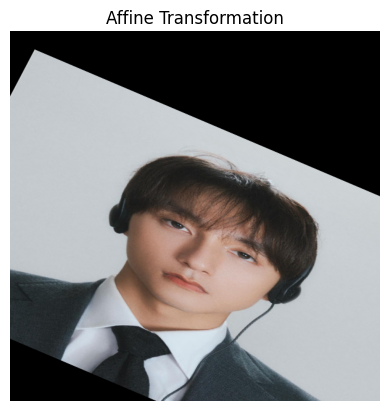

In [77]:
theta = np.deg2rad(30)
sx, sy = 1.2, 0.8

theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

shx = 1/np.tan(theta_x)
shy = 1/np.tan(theta_y)

tx, ty = 40, 30

affine_matrix = np.array([
    [
        sx * np.cos(theta) + shx * sy * np.sin(theta),
        -sx * np.sin(theta) + shx * sy * np.cos(theta),
        tx
    ],
    [
        shy * sx * np.cos(theta) + (1 + shx * shy) * sy * np.sin(theta),
        -shy * sx * np.sin(theta) + (1 + shx * shy) * sy * np.cos(theta),
        ty
    ],
], dtype=np.float32)

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

### Suy ma trận affine từ các điểm tương ứng

Ma trận M =
 [[ 7.01168614e-01 -5.00834725e-02  8.00000000e+01]
 [-5.00834725e-02  8.34724541e-01  5.00000000e+01]]


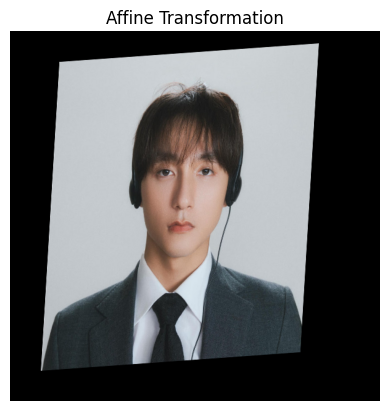

In [78]:
pts1 = np.array([
    [0, 0],       
    [w-1, 0],        
    [0, h-1],       
],dtype=np.float32)

pts2 = np.array([
    [80, 50],        
    [w-100, 20],     
    [50, h-50],          
],dtype=np.float32)

M = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(img, M, (w, h))

print("Ma trận M =\n", M)

show_plt("Affine Transformation", affine)

## Projective transformation

Ma trận H =
 [[ 6.91614346e-01 -6.60072523e-02  8.00000000e+01]
 [-5.04656432e-02  6.59562962e-01  5.00000000e+01]
 [-1.91085358e-05 -3.18475597e-04  1.00000000e+00]]


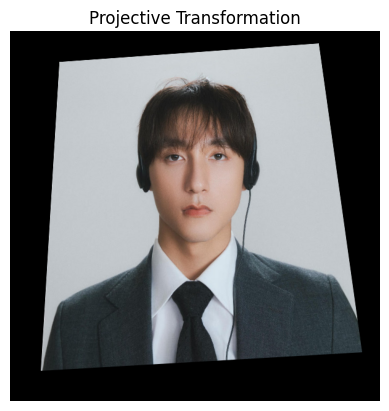

In [79]:
src_points = np.array([
    [0, 0],         
    [w-1, 0],        
    [0, h-1],
    [w-1, h-1]    
], dtype=np.float32)

dst_points = np.array([
    [80, 50],        
    [w-100, 20],     
    [50, h-50],      
    [w-30, h-80]     
], dtype=np.float32)

# dùng cho 4 điểm
H = cv2.getPerspectiveTransform(src_points, dst_points)

# # dùng cho nhiều điểm
# H,_ = cv2.findHomography(src_points, dst_points)

perspective_img = cv2.warpPerspective(img, H, (w, h))

print("Ma trận H =\n", H)

show_plt("Projective Transformation", perspective_img)